In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit

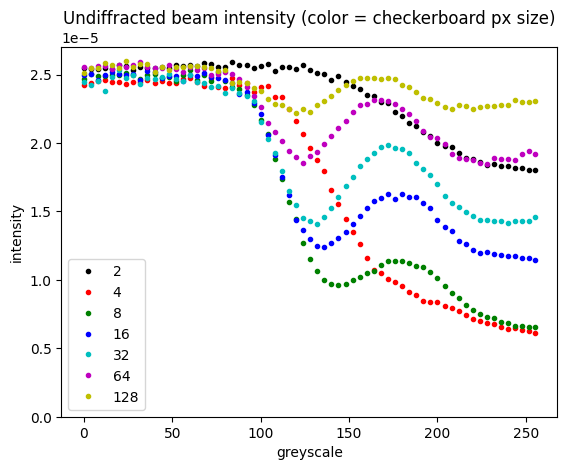

In [3]:
g, p = np.loadtxt('slmcali/20260529_135906_binary_calib_checkerboard_period2.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'k.', label='2')

g, p = np.loadtxt('slmcali/20260529_133559_binary_calib_checkerboard_period4.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'r.', label='4')

g, p = np.loadtxt('slmcali/20260529_134230_binary_calib_checkerboard_period8.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'g.', label='8')

g, p = np.loadtxt('slmcali/20260529_134305_binary_calib_checkerboard_period16.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'b.', label='16')

g, p = np.loadtxt('slmcali/20260529_134005_binary_calib_checkerboard_period32.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'c.', label='32')

g, p = np.loadtxt('slmcali/20260529_140453_binary_calib_checkerboard_period64.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'm.', label='64')

g, p = np.loadtxt('slmcali/20260529_140403_binary_calib_checkerboard_period128.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'y.', label='128')

plt.legend()
plt.title('Undiffracted beam intensity (color = checkerboard px size)')
plt.ylabel('intensity')
plt.xlabel('greyscale')
plt.ylim(bottom=0)
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
import pandas as pd

# ==========================================
# CALIBRATION FUNCTIONS
# ==========================================

def moving_average(x, window_size=5):
    return np.convolve(x, np.ones(window_size)/window_size, mode='valid')

def meadowlark_diffractive_calibration(g, p, output_bit_depth=12):
    # 1. Apply Moving Average
    pad_width = 5 // 2
    p_padded = np.pad(p, (pad_width, pad_width), mode='edge')
    p_smooth = moving_average(p_padded, window_size=5)
    
    # 2. Find Extrema for 0th Order
    peaks, _ = find_peaks(p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    valleys, _ = find_peaks(-p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    
    idx_0 = 0 
    
    valid_valleys = [v for v in valleys if v > idx_0]
    idx_pi = valid_valleys[0] if valid_valleys else np.argmin(p_smooth)
            
    valid_peaks_2pi = [p_idx for p_idx in peaks if p_idx > idx_pi]
    if valid_peaks_2pi:
        idx_2pi = valid_peaks_2pi[0]
    else:
        idx_2pi = idx_pi + np.argmax(p_smooth[idx_pi:]) if idx_pi < len(p_smooth) - 1 else len(p_smooth) - 1
            
    if idx_pi <= idx_0: idx_pi = idx_0 + 1
    if idx_2pi <= idx_pi: idx_2pi = idx_pi + 1
        
    idx_pi = min(idx_pi, len(g) - 2)
    idx_2pi = min(idx_2pi, len(g) - 1)

    # 3. Convert Intensity to Phase (FIXED FOR CONTINUITY)
    p_min = p_smooth[idx_pi]
    p_max1 = p_smooth[idx_0]
    p_max2 = p_smooth[idx_2pi]
    
    # Segment 1: 0 to pi
    g_seg1 = g[idx_0:idx_pi]
    p_seg1 = p_smooth[idx_0:idx_pi]
    p_norm1 = np.clip((p_seg1 - p_min) / (p_max1 - p_min + 1e-8), 0, 1)
    phase_seg1 = 2 * np.arccos(np.sqrt(p_norm1))
    
    # Segment 2: pi to 2pi
    g_seg2 = g[idx_pi:idx_2pi+1]
    p_seg2 = p_smooth[idx_pi:idx_2pi+1]
    p_norm2 = np.clip((p_seg2 - p_min) / (p_max2 - p_min + 1e-8), 0, 1)
    phase_seg2 = 2 * np.pi - 2 * np.arccos(np.sqrt(p_norm2))
    
    # Combine the segments
    g_joined = np.concatenate([g_seg1, g_seg2])
    phase_joined_raw = np.concatenate([phase_seg1, phase_seg2])
    p_smooth_joined = np.concatenate([p_seg1, p_seg2]) 
    
    # Apply a Savitzky-Golay filter
    window_length = min(15, len(phase_joined_raw))
    if window_length % 2 == 0: 
        window_length -= 1
        
    if window_length >= 3:
        phase_joined = savgol_filter(phase_joined_raw, window_length, polyorder=3)
    else:
        phase_joined = phase_joined_raw
        
    # Ensure monotonicity
    phase_joined = np.maximum.accumulate(phase_joined)
    
    # 4. Calculate Intensity from Smoothed Phase (FIXED FOR UNEQUAL PEAKS)
    # Reconstruct the intensity piecewise using the separate max amplitudes
    split_idx = len(phase_seg1)
    phase_joined_seg1 = phase_joined[:split_idx]
    phase_joined_seg2 = phase_joined[split_idx:]
    
    intensity_fit_seg1 = (p_max1 - p_min) * np.cos(phase_joined_seg1 / 2)**2 + p_min
    intensity_fit_seg2 = (p_max2 - p_min) * np.cos(phase_joined_seg2 / 2)**2 + p_min
    
    intensity_from_phase_smoothed = np.concatenate([intensity_fit_seg1, intensity_fit_seg2])
    
    # Pack the requested intensities into a dictionary
    extra_data = {
        'g_raw': g,
        'intensity_raw': p,
        'intensity_smoothed': p_smooth,
        'intensity_from_phase_smoothed': intensity_from_phase_smoothed,
        'g_joined': g_joined, 
    }
    
    return p_smooth, g_joined, phase_joined, extra_data

def process_and_extrapolate(files, periods):
    phases_interp = []
    raw_intensities = []
    common_g = np.arange(0, 256) 
    
    for file in files:
        try:
            g, p = np.loadtxt(file, delimiter=',').T
            g = g // 256 
        except OSError:
            # Fallback mock data if files are not found
            g = np.arange(256)
            p = np.cos(np.linspace(0, 1.2*np.pi, 256))**2 + np.random.normal(0, 0.05, 256) 
            
        p_smooth, g_raw, phase_raw, _ = meadowlark_diffractive_calibration(g, p)
        phases_interp.append(np.interp(common_g, g_raw, phase_raw))
        
        raw_intensities.append((g, p, p_smooth))
        
    phases_interp = np.array(phases_interp) 
    inv_periods = 1.0 / np.array(periods)
    extrapolated_phase = np.zeros_like(common_g, dtype=float)
    
    for i in range(len(common_g)):
        coeffs = np.polyfit(inv_periods, phases_interp[:, i], 1)
        extrapolated_phase[i] = coeffs[1] 
        
    # --- PIECEWISE FIT LOGIC ---
    idx_pi_extrap = np.argmax(extrapolated_phase >= np.pi)
    if idx_pi_extrap == 0: idx_pi_extrap = len(common_g) // 2
    
    g_half1 = common_g[:idx_pi_extrap+1]
    phase_half1 = extrapolated_phase[:idx_pi_extrap+1]
    
    def sigmoid(x, L, x0, k, b):
        return L / (1 + np.exp(-k * (x - x0))) 
        
    p0_sig = [np.pi, np.median(g_half1), 0.1, 0]
    try:
        popt_sig, _ = curve_fit(sigmoid, g_half1, phase_half1, p0=p0_sig, maxfev=10000)
    except RuntimeError:
        popt_sig = p0_sig

    g_crossover = common_g[idx_pi_extrap]
    phase_crossover = sigmoid(g_crossover, *popt_sig)
    
    def constrained_poly(x, a, b):
        return a * (x - g_crossover)**2 + b * (x - g_crossover) + phase_crossover

    truncation_limit = 1.95 * np.pi 
    valid_poly_indices = np.where((extrapolated_phase >= np.pi) & (extrapolated_phase <= truncation_limit))[0]
    
    if len(valid_poly_indices) > 3:
        g_half2_fit = common_g[valid_poly_indices]
        phase_half2_fit = extrapolated_phase[valid_poly_indices]
        popt_poly, _ = curve_fit(constrained_poly, g_half2_fit, phase_half2_fit)
        def poly_func(x): return constrained_poly(x, *popt_poly)
    else:
        def poly_func(x): return constrained_poly(x, 0, 0.05)

    def piecewise_fit(x):
        x = np.asarray(x)
        y = np.zeros_like(x, dtype=float)
        mask1 = x <= common_g[idx_pi_extrap]
        mask2 = ~mask1
        y[mask1] = sigmoid(x[mask1], *popt_sig)
        y[mask2] = poly_func(x[mask2])
        return y

    g_search = np.linspace(common_g[idx_pi_extrap], 255, 5000)
    phase_search = poly_func(g_search)
    
    idx_2pi_fit = np.argmax(phase_search >= 2 * np.pi)
    if idx_2pi_fit == 0:
        g_2pi_fit = 255 
    else:
        g_2pi_fit = g_search[idx_2pi_fit]
    
    target_phases = np.linspace(0, 2 * np.pi, 256)
    g_dense = np.linspace(0, g_2pi_fit, 1000)
    phase_dense = piecewise_fit(g_dense)
    
    phase_dense = np.maximum.accumulate(phase_dense)
    phase_dense[-1] = max(phase_dense[-1], 2 * np.pi) 
    
    lut_input_g = np.interp(target_phases, phase_dense, g_dense)
    lut_final = (lut_input_g / 255.0) * 255.0
    
    return np.round(lut_final).astype(int), common_g, extrapolated_phase, piecewise_fit, g_2pi_fit, phases_interp, raw_intensities

In [5]:
# ==========================================
# DATA PROCESSING
# ==========================================

files = [
    # 'slmcali/20260529_134230_binary_calib_checkerboard_period8.csv',
    'slmcali/20260529_134305_binary_calib_checkerboard_period16.csv',
    'slmcali/20260529_134005_binary_calib_checkerboard_period32.csv',
    'slmcali/20260529_140453_binary_calib_checkerboard_period64.csv',
    'slmcali/20260529_140403_binary_calib_checkerboard_period128.csv'
]
periods = [16, 32, 64, 128]

# Process standard 8-bit LUT and Extrapolation
lut_8bit, common_g_8bit, extrapolated_phase, piecewise_fit, g_2pi_fit, phases_interp_8bit, raw_intensities_8bit = process_and_extrapolate(files, periods)

raw_intensities = []
phases_interp = []

for file, period in zip(files, periods):
    try:
        df = pd.read_csv(file)
        if 'g' in df.columns and 'p' in df.columns:
            g = df['g'].values
            p = df['p'].values
        else:
            g = df.iloc[:, 0].values
            p = df.iloc[:, 1].values
    except OSError:
        # Fallback mock data if files are not found
        g = np.linspace(0, 65535, 256)
        p = np.cos(np.linspace(0, 1.2*np.pi, 256))**2 + np.random.normal(0, 0.05, 256)

    # Dynamically create common_g based on the actual data range
    common_g = np.linspace(g.min(), g.max(), 1000)

    # Process the data
    p_smooth, g_joined, phase_joined, extra_data = meadowlark_diffractive_calibration(g, p, output_bit_depth=16)
    
    # Add phase_joined to extra_data so we can perfectly fit it in the plot
    extra_data['phase_joined'] = phase_joined
    extra_data['common_g'] = common_g
    raw_intensities.append(extra_data)
    
    # Interpolate phase to the new 16-bit common_g
    phase_interpolated = np.interp(common_g, g_joined, phase_joined)
    phases_interp.append(phase_interpolated)
    
    print(f"Processed period {period}")



Processed period 16
Processed period 32
Processed period 64
Processed period 128


C:\Users\rst5\AppData\Local\Temp\ipykernel_30740\3030451045.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_sig, _ = curve_fit(sigmoid, g_half1, phase_half1, p0=p0_sig, maxfev=10000)


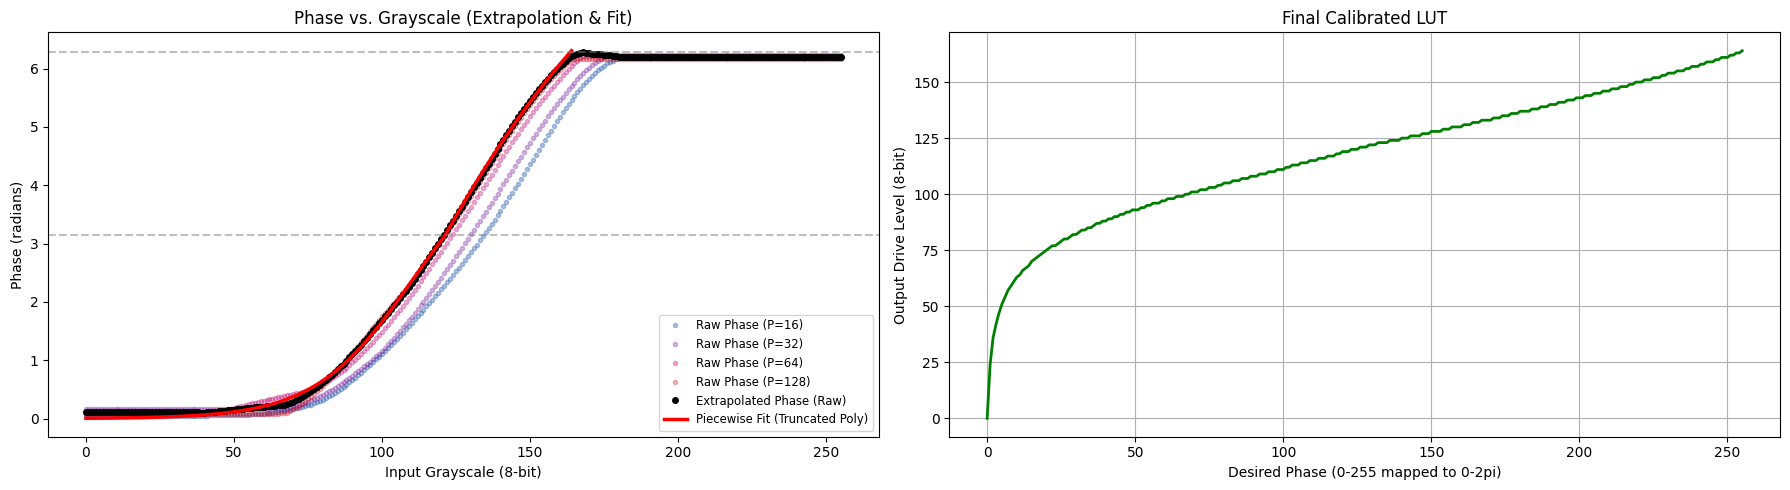

In [12]:
# ==========================================
# ORIGINAL 3-PANEL FIGURE
# ==========================================
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(18, 5))

# Plot 2: Extrapolated Phase & Piecewise Fit
plt.subplot(1, 2, 1)
hex_colors = ['#00429d', '#5e229e', '#9a008d', '#c80064', '#d31224']

# Create a custom colormap
custom_cmap = LinearSegmentedColormap.from_list("blue_purple_red", hex_colors)

# Generate exactly the number of colors you need based on your files
num_datasets = len(files)
colors = custom_cmap(np.linspace(0, 1, num_datasets))

for i, period in enumerate(periods):
    plt.plot(common_g_8bit, phases_interp_8bit[i], '.', color=colors[i%len(colors)], alpha=0.3, label=f'Raw Phase (P={period})')

plt.plot(common_g_8bit, extrapolated_phase, 'ko', markersize=4, label='Extrapolated Phase (Raw)')
g_plot = np.linspace(min(lut_8bit), max(lut_8bit), 500) 
plt.plot(g_plot, piecewise_fit(g_plot), 'r-', lw=2.5, label='Piecewise Fit (Truncated Poly)')

plt.axhline(np.pi, color='gray', linestyle='--', alpha=0.5)
plt.axhline(2*np.pi, color='gray', linestyle='--', alpha=0.5)
plt.title('Phase vs. Grayscale (Extrapolation & Fit)')
plt.xlabel('Input Grayscale (8-bit)')
plt.ylabel('Phase (radians)')
plt.legend(fontsize='small')

# Plot 3: Final Calibrated LUT
plt.subplot(1, 2, 2)
plt.plot(np.arange(256), lut_8bit, 'g-', lw=2)
plt.title('Final Calibrated LUT')
plt.xlabel('Desired Phase (0-255 mapped to 0-2pi)')
plt.ylabel('Output Drive Level (8-bit)')
plt.grid(True)

plt.tight_layout()
plt.show()


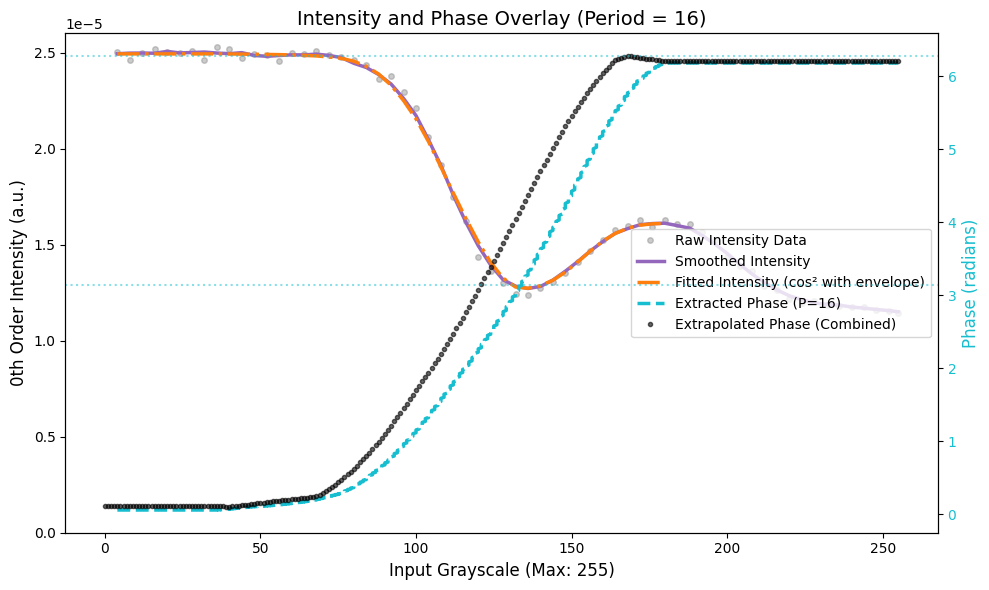

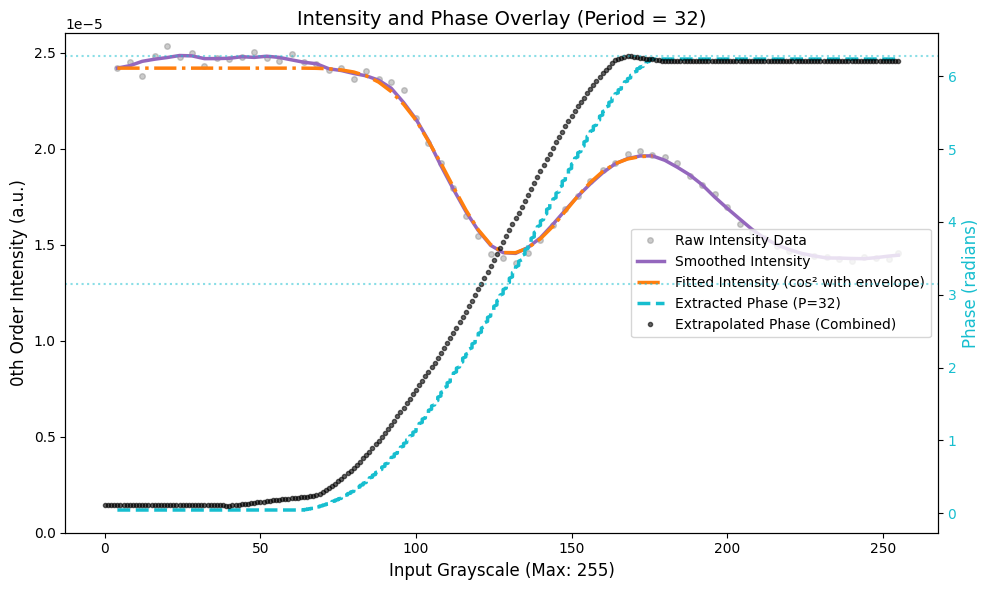

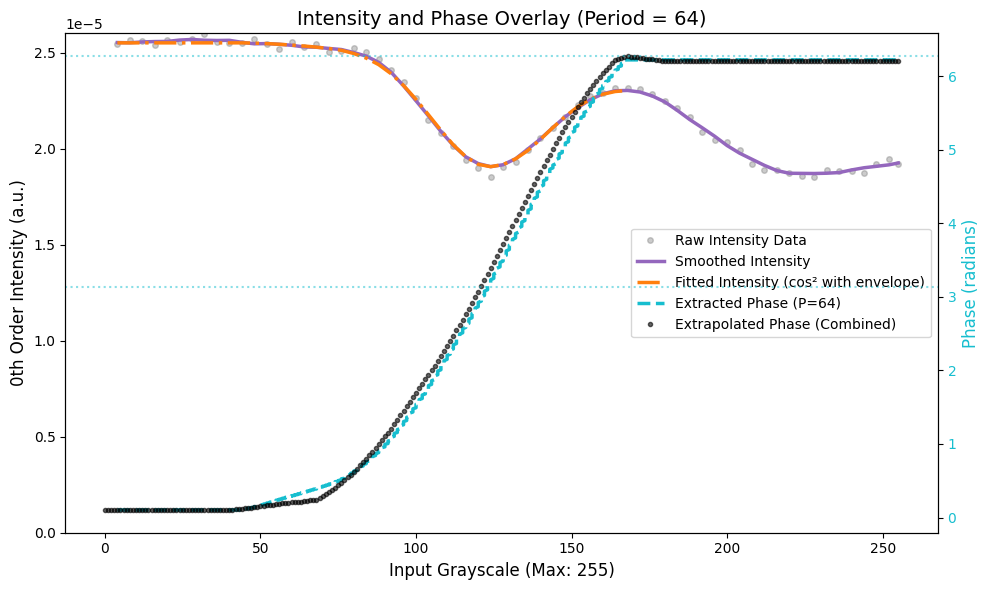

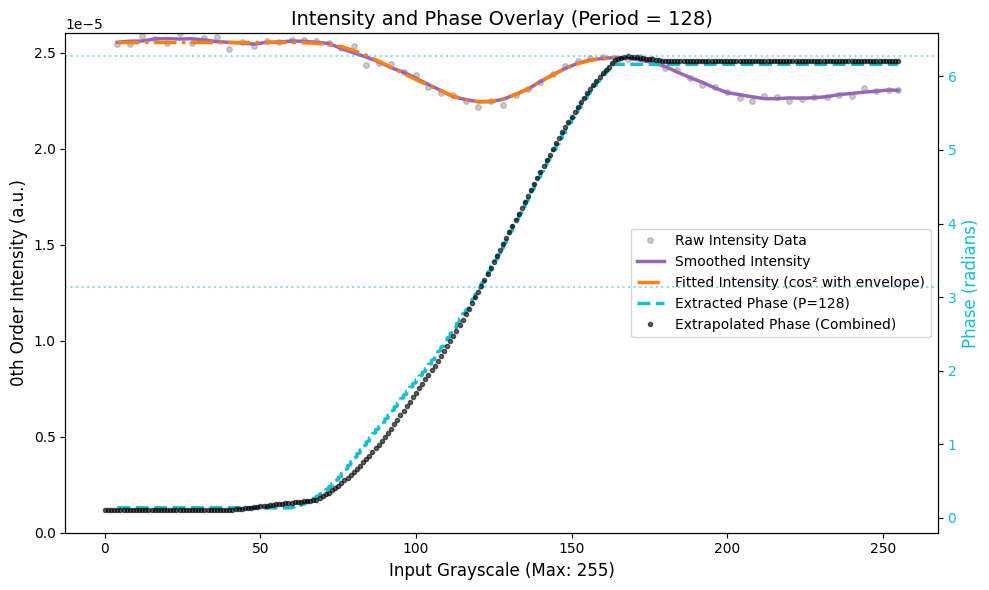

In [11]:
# ==========================================
# NEW SEPARATE FIGURE: Intensity & Phase Overlay (Single Dataset)
# ==========================================

# Extract data for the selected dataset
for id in range(len(files)):
    plt.figure(figsize=(10, 6))
    ax1 = plt.gca()
    extra_data = raw_intensities[id]  
    phase_extracted_interp = phases_interp[id]

    # Extract arrays
    g_raw = extra_data['g_raw'] // 256
    p_raw = extra_data['intensity_raw']       
    p_smooth = extra_data['intensity_smoothed'] 
    g_joined = extra_data['g_joined'] // 256
    common_g = extra_data['common_g'] // 256

    # --- 1. Use the calibration function's native fitted intensity ---
    fitted_intensity = extra_data['intensity_from_phase_smoothed']

    # --- 2. Plot Intensities on Left Y-Axis ---
    color_raw = 'tab:gray'
    color_smooth = 'tab:purple'
    color_fit_int = 'tab:orange'

    ax1.set_xlabel(f'Input Grayscale (Max: {int(g_raw.max())})', fontsize=12)
    ax1.set_ylabel('0th Order Intensity (a.u.)', color='black', fontsize=12)

    # Raw and Smoothed (plotted against original 64-point g_raw)
    ax1.plot(g_raw, p_raw, 'o', color=color_raw, alpha=0.4, markersize=4, label='Raw Intensity Data')
    ax1.plot(g_raw, p_smooth, '-', color=color_smooth, lw=2.5, label='Smoothed Intensity')
    ax1.set_ylim(bottom=0)
    ax1.set_ylim(top=2.6e-5)

    # Fitted Intensity (plotted against g_joined so it spans exactly the extracted region)
    ax1.plot(g_joined, fitted_intensity, '-.', color=color_fit_int, lw=2.5, label='Fitted Intensity (cos² with envelope)')
    ax1.tick_params(axis='y', labelcolor='black')

    # --- 3. Plot Extracted Phase on Right Y-Axis ---
    ax2 = ax1.twinx()
    color_ph = 'tab:cyan'

    ax2.set_ylabel('Phase (radians)', color=color_ph, fontsize=12)
    
    # Plotted against the correct common_g for this specific dataset
    ax2.plot(common_g, phase_extracted_interp, '--', color=color_ph, lw=2.5, label=f'Extracted Phase (P={periods[id]})')
    
    # Add the Combined Extrapolated Phase (Black Dots)
    # Scale the 8-bit common_g_8bit to match the current x-axis scale (e.g., if g_raw is 16-bit)
    g_scale = g_raw.max() / 255.0 if g_raw.max() > 255 else 1.0
    ax2.plot(common_g_8bit * g_scale, extrapolated_phase, 'ko', markersize=3, alpha=0.6, label='Extrapolated Phase (Combined)')

    ax2.tick_params(axis='y', labelcolor=color_ph)

    # Reference lines for phase
    ax2.axhline(np.pi, color=color_ph, linestyle=':', alpha=0.5)
    ax2.axhline(2*np.pi, color=color_ph, linestyle=':', alpha=0.5)

    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.title(f'Intensity and Phase Overlay (Period = {periods[id]})', fontsize=14)
    plt.tight_layout()
    plt.show()